<a href="https://colab.research.google.com/github/IshikaSharma011/LP-2/blob/main/miniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import re
from datetime import datetime

In [6]:
with open("access.log", "r") as file:
    logs = file.readlines()

print("Total log lines:", len(logs))

Total log lines: 7


In [7]:
pattern = r'(\d+\.\d+\.\d+\.\d+) - - \[(.*?)\] "(.*?)" (\d+) (\d+)'

parsed_data = []

for log in logs:
    match = re.match(pattern, log)
    if match:
        ip = match.group(1)
        timestamp = match.group(2)
        request = match.group(3)
        status = int(match.group(4))
        size = int(match.group(5))

        parsed_data.append([ip, timestamp, request, status, size])

df = pd.DataFrame(parsed_data, columns=["IP", "Timestamp", "Request", "Status", "Size"])
df.head()

,IP,Timestamp,Request,Status,Size
0,192.168.1.1,10/Oct/2023:14:01:22,POST /login HTTP/1.1,401,721
1,10.0.0.2,10/Oct/2023:14:05:10,GET /home HTTP/1.1,200,1024


In [8]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%d/%b/%Y:%H:%M:%S")

In [9]:
df["IP"].value_counts().head()

,count
IP,
192.168.1.1,1
10.0.0.2,1


In [10]:
df["Status"].value_counts()

,count
Status,
401,1
200,1


In [11]:
df["Request"].value_counts().head()

,count
Request,
POST /login HTTP/1.1,1
GET /home HTTP/1.1,1


In [12]:
df["Hour"] = df["Timestamp"].dt.hour
df.groupby("Hour").size()

,0
Hour,
14,2


In [13]:
ip_counts = df["IP"].value_counts()
suspicious_ips = ip_counts[ip_counts > 100]

print(suspicious_ips)

Series([], Name: count, dtype: int64)


In [14]:
errors = df[df["Status"] >= 400]
errors["IP"].value_counts().head()

,count
IP,
192.168.1.1,1


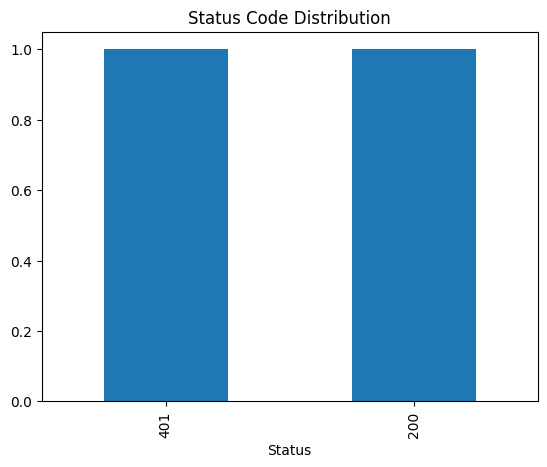

In [15]:
import matplotlib.pyplot as plt

df["Status"].value_counts().plot(kind="bar")
plt.title("Status Code Distribution")
plt.show()

In [16]:
df.to_csv("processed_logs.csv", index=False)